# Seed Node Identification in Erdős-Rényi Graphs

**Algorithms benchmarked:**
- **BP** — Belief Propagation with EM prior estimation
- **NetFill** — Graph-diffusion baseline
- **MILP** — Mixed Integer Linear Programming 

Run every cell top-to-bottom. Results are saved to CSV and visualised at the end.

## 0. Setup (Google Colab only)

**Skip this cell if running locally.**

Upload the project folder to Colab, then run the cell below:

In [ ]:
# # ── Google Colab Setup ──────────────────────────────────────────────────────
# # Option A: mount Google Drive (recommended)
# from google.colab import drive
# drive.mount('/content/drive')
# import os
# os.chdir('/content/drive/MyDrive/seed_nodes_er_graph')  # adjust path

# # Option B: upload a zip, then unzip
# # from google.colab import files
# # files.upload()                                          # upload the .zip
# # !unzip seed_nodes_er_graph.zip -d /content/
# # import os
# # os.chdir('/content/seed_nodes_er_graph')

# # Install dependencies
# !pip install -q pyscipopt networkx torch scipy numpy pandas matplotlib

## 1. Imports

In [1]:
import pandas as pd
import torch

from run_experiments import run_benchmark, save_raw_data_to_csv
from utils.plotting import plot_bar_chart, plot_horizontal_runtime_chart



In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [ ]:
# %load_ext autoreload
# %autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 2. Experiment Parameters

Edit the values below to configure the benchmark.

In [3]:
# ── Experiment configuration ─────────────────────────────────────────────────
N          = 7000    # number of nodes in the ER graph
NUM_SEEDS  = 300     # true number of seed nodes
BETA       = 0.25   # SI infection probability
P_NOISE    = 0.1    # observation noise probability
AVG_DEGREE = 10   # average node degree
NUM_RUNS   = 1      # number of independent trials

CSV_FILE   = f'results_N{N}_K{NUM_SEEDS}_p{P_NOISE}_d{AVG_DEGREE}.csv'

ALGORITHMS = ('BP', 'ILP', 'MILP', 'NetFill')

print('Parameters set ✅')

Parameters set ✅


## 3. Run Benchmark

In [4]:

raw_data = run_benchmark(
    N=N, NUM_SEEDS=NUM_SEEDS, BETA=BETA, P_NOISE=P_NOISE,
    AVG_DEGREE=AVG_DEGREE, num_runs=NUM_RUNS,
    csv_filename=CSV_FILE, algorithms=ALGORITHMS
)
print('\n✅ Benchmark complete!')


  RUN 1 / 1
BENCHMARK STARTING
  Device     : cpu
  Nodes      : 7000 | Seeds: 300 | Beta: 0.25 | Noise: 0.1
  Avg Degree : 10
  Algorithms : BP, ILP, MILP, NetFill
------------------------------------------------------------
[1] Generating data (ER graph + SI simulation)...


/home/bvthach/erdos renyi/run_experiments.py:64: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  torch.sparse_coo_tensor(indices_a, values_a, (N, N))


    Data ready. Observed infected nodes: 895
------------------------------------------------------------

[BP] Running algorithm: Belief Propagation (BP)...
    EM prior estimation starting. Init pi: 0.06857
    EM converged at iter 5. Optimal pi = 0.04221
🚀 Starting BP  on cpu...
🔹  Running Final BP with Prior =0.04...
   [Decision] Selected 233 seeds.
>>> Total Seeds Found: 233
    Optimal pi: 0.04221
   >> BP Finished in 0.2991s

[NetFill] Running algorithm: NetFill...


/home/bvthach/erdos renyi/algorithms/baseline.py:26: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  D = sp.diags(degrees)
/home/bvthach/erdos renyi/algorithms/baseline.py:373: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  sub_D = sp.diags(degrees)


Iter 0: Old C size = 4285, New C size = 0
Iter 1: Old C size = 0, New C size = 0
Iter 2: Old C size = 0, New C size = 0
   >> NETFILL Finished in 70.5996s

[ILP] Running algorithm: Deterministic ILP (no beta / p_noise)...
Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /home/bvthach/erdos renyi/venv/lib/python3.13/site-packages/pulp/apis/../solverdir/cbc/linux/i64/cbc /tmp/4376fb0175044ae4b6550b5727022438-pulp.mps -sec 120 -timeMode elapsed -branch -printingOptions all -solution /tmp/4376fb0175044ae4b6550b5727022438-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 162540 COLUMNS
At line 746676 RHS
At line 909212 BOUNDS
At line 1000533 ENDATA
Problem MODEL has 162535 rows, 91320 columns and 394495 elements
Coin0008I MODEL read with 0 errors
seconds was changed from 1e+100 to 120
Option for timeMode changed from cpu to elapsed
Continuous objective value is 221.11 - 57.32 seconds
Cgl0004I processed model has 14408

## 4. Load & Summarise Results

In [5]:
df = pd.read_csv(CSV_FILE)
mean_df = df.groupby('Algorithm')[['Precision', 'Recall', 'F1-Score', 'Runtime']].mean()
print('Average results across runs:')
display(mean_df.round(4))

mean_metrics_dict = mean_df[['Precision', 'Recall', 'F1-Score']].to_dict('index')
mean_runtime_dict = mean_df['Runtime'].to_dict()

Average results across runs:


,Precision,Recall,F1-Score,Runtime
Algorithm,,,,
BP,0.8069,0.6267,0.7054,0.2991
ILP,0.5385,0.4200,0.4719,220.9504
MILP,0.6776,0.5533,0.6092,70.6914
NetFill,1.0000,0.0033,0.0066,70.5996


## 5. Visualise: Performance Metrics

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


📸 Đã lưu biểu đồ tại: /home/bvthach/erdos renyi/plots/fig_performance.eps


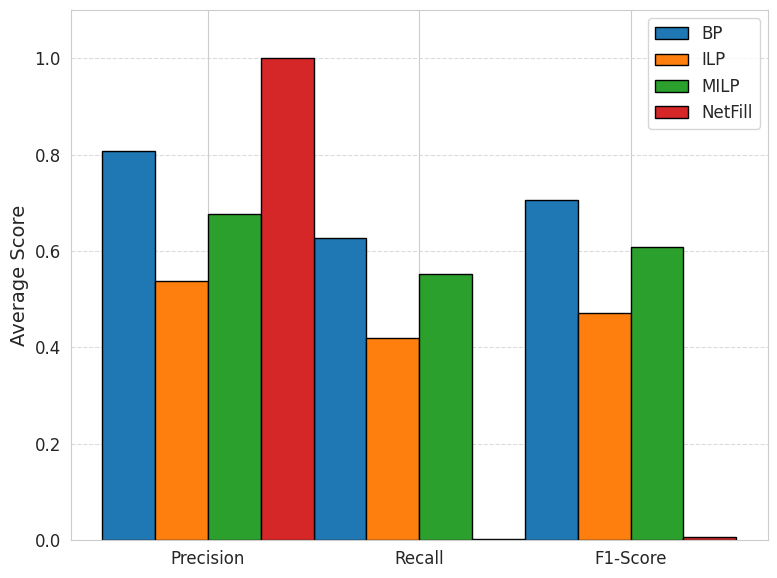

In [6]:
plot_bar_chart(
    metrics_dict=mean_metrics_dict,
    title=f'Average Performance over {NUM_RUNS} runs\n(N={N}, K={NUM_SEEDS}, Beta={BETA}, p={P_NOISE})',
    ylabel='Average Score',
    filename='fig_performance'
)

## 6. Visualise: Runtime Comparison

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


📸 Đã lưu biểu đồ tại: /home/bvthach/erdos renyi/plots/fig_runtime.eps


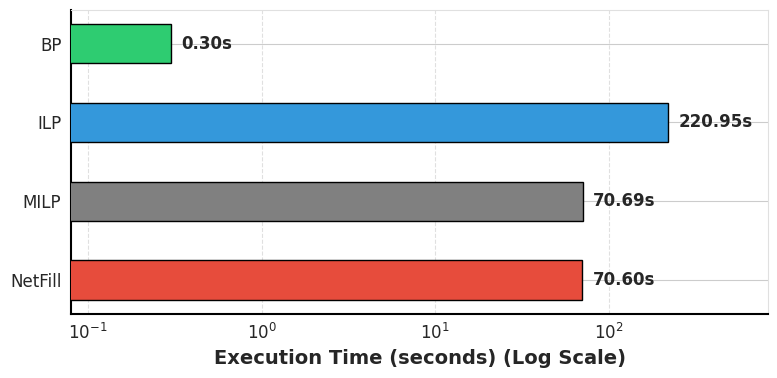

In [7]:
plot_horizontal_runtime_chart(
    runtime_dict=mean_runtime_dict,
    xlabel='Execution Time (seconds)',
    filename='fig_runtime'
)